In [3]:
import utils
from BenchmarkProblems.Trapk import Trapk
from tqdm import tqdm
from Core.PS import PS
from Core.SearchSpace import SearchSpace
from Core.FullSolution import FullSolution
import numpy as np
import itertools

from Core.PRef import PRef
from BenchmarkProblems.BenchmarkProblem import BenchmarkProblem

def combinations_of_cardinalities(cardinalities):
    return np.array(np.meshgrid(*[np.arange(c) for c in cardinalities])).T.reshape(-1, len(cardinalities))


def get_enumerated_pRef(problem: BenchmarkProblem) -> PRef:
    solutions = combinations_of_cardinalities(problem.search_space.cardinalities)
    fitnesses = np.array([problem.fitness_function(FullSolution(row)) for row in solutions])
    return PRef(fitness_array=fitnesses, search_space=problem.search_space, full_solution_matrix=solutions)


def get_patterns(search_space: SearchSpace,  max_order: int) -> list[PS]:
    def get_all_patterns_at_locations(indices: list[int]):
        if len(indices) == 0:
            return [PS.empty(search_space)]
        cardinalities = search_space.cardinalities[list(indices)]
        combinations = combinations_of_cardinalities(cardinalities)
        ps_values = np.full(shape=(len(combinations), search_space.amount_of_parameters), fill_value=-1, dtype=int)
        for index, values in zip(indices, combinations.T):
            ps_values[:, index] = values
        
        return [PS(row) for row in ps_values]
    
    
    all_pss = []
    for order in range(max_order+1):
        for indices in itertools.combinations(range(search_space.amount_of_parameters), r=order):
            all_pss.extend(get_all_patterns_at_locations(indices))
    return all_pss



def get_proper_subsets_of_ps(ps: PS) -> set[PS]:
    subsets = {ps}
    indices = ps.get_fixed_variable_positions()
    
    for index in indices:
        to_add = {s.with_unfixed_value(index) for s in subsets}
        subsets.update(to_add)
    
    subsets.remove(ps)
    return subsets

def get_effect_of_ps(ps: PS, pRef: PRef, pRef_dict: dict) -> float:
    with_ps = pRef.get_indexes_matching_ps(ps)
    without_ps = set(range(pRef.sample_size)).difference(with_ps)
    without_ps = list(without_ps)
    solutions_without_ps = pRef.full_solution_matrix[without_ps]
    fitnesses_without_ps = pRef.fitness_array[without_ps]
    
    matrix_with_forced_pattern = solutions_without_ps.copy()
    for ps_fixed_index in ps.get_fixed_variable_positions():
        matrix_with_forced_pattern[:, ps_fixed_index] = ps.values[ps_fixed_index]
    
    forced_solutions = [FullSolution(row) for row in matrix_with_forced_pattern]
    fitnesses_after_forcing = np.array([pRef_dict[sol] for sol in forced_solutions])
    
    signs = np.sign(fitnesses_after_forcing - fitnesses_without_ps)
    improvements = np.sum(signs == 1)
    
    if len(signs) == 0:
        return 0
    else:
        return improvements / (len(signs))
    
    
def get_scores_for_pss(pss: list[PS], pRef: PRef) -> list[(PS, float, float)]:
    print(f"Generating pRef dict")
    pRef_dict = {FullSolution(row): fitness for row,fitness in zip(pRef.full_solution_matrix, pRef.fitness_array)}
    print(f"Generating ps dict")
    ps_improvement_dict = {ps: get_effect_of_ps(ps, pRef, pRef_dict)
                           for ps in pss}
    
    def get_atomicity(ps: PS):
        own_effect = ps_improvement_dict[ps]
        own_subsets = get_proper_subsets_of_ps(ps)
        best_sub_effect = max([ps_improvement_dict[sub] for sub in own_subsets]) if own_subsets else own_effect
        return own_effect - best_sub_effect

    return [(ps, ps_improvement_dict[ps], get_atomicity(ps))
            for ps in pss]
    


In [ ]:
from BenchmarkProblems.RoyalRoad import RoyalRoad

problem = Trapk(3, 4)
enumerated_pRef = get_enumerated_pRef(problem)

pss = get_patterns(problem.search_space, max_order=4)
pss_scores = get_scores_for_pss(pss, enumerated_pRef)

for ps, effect, atomicity in pss_scores:
    print(ps, effect, atomicity)

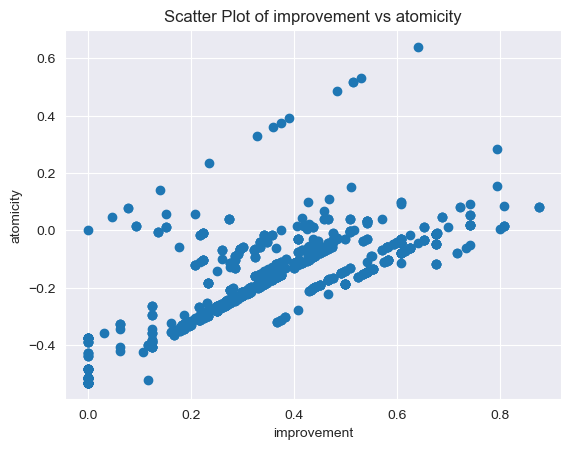

[0 * * * * * *]
[1 * 0 0 * * *]
[1 0 0 0 * * *]
[0 0 1 1 * * *]
[1 * 0 0 0 * *]
[1 * 0 0 * * 0]


In [8]:
import utils

def get_pareto_optimal_indices(objectives):
    def dominates(a, b):
        return np.all(a >= b) and np.any(a > b)
    
    def is_pareto_optimal(i):
        row = objectives[i]
        return not any(dominates(other_row, row) for j, other_row in enumerate(objectives) if j != i)
    
    return [i for i in range(len(objectives)) if is_pareto_optimal(i)]

objectives = np.array([[improvement, atomicity] for ps,improvement, atomicity in pss_scores])
utils.simple_scatterplot(xs = objectives[:, 0].ravel(), ys = objectives[:, 1].ravel(), x_label="improvement", y_label="atomicity")
#print(objectives)
po_indices = get_pareto_optimal_indices(objectives)
optimal_pss = [pss_scores[index][0] for index in po_indices]

for ps in optimal_pss:
    print(ps)




In [4]:




class SmallKnapsack(BenchmarkProblem):
    weights: np.ndarray
    values: np.array
    max_capacity: int
    
    def __init__(self):
        self.weights = np.array([31, 10, 20, 19, 4, 3, 6])
        self.values = np.array([70, 20, 39, 37, 7, 5, 10])
        self.max_capacity = 50
        
        super().__init__(SearchSpace([2 for _ in range(7)]))
        
    def fitness_function(self, fs: FullSolution) -> float:
        active_items = fs.values == 1
        total_weight = np.sum(self.weights[active_items])
        if total_weight > self.max_capacity:
            return 0
        else:
            return float(np.sum(self.values[active_items]))
        
        
k_problem = SmallKnapsack()
k_PRef = get_enumerated_pRef(k_problem)
best_k = k_PRef.get_best_solution()
print(best_k)

(1 0 0 1 0 0 0), fs score = 107.00


In [16]:
pss = get_patterns(k_problem.search_space, max_order=7)
pss_scores = get_scores_for_pss(pss, k_PRef)

for ps, effect, atomicity in pss_scores:
    print(ps, effect, atomicity)

Generating pRef dict
Generating ps dict
[* * * * * * *] 0 0
[0 * * * * * *] 0.640625 0.640625
[1 * * * * * *] 0.234375 0.234375
[* 0 * * * * *] 0.140625 0.140625
[* 1 * * * * *] 0.484375 0.484375
[* * 0 * * * *] 0.359375 0.359375
[* * 1 * * * *] 0.375 0.375
[* * * 0 * * *] 0.328125 0.328125
[* * * 1 * * *] 0.390625 0.390625
[* * * * 0 * *] 0.078125 0.078125
[* * * * 1 * *] 0.515625 0.515625
[* * * * * 0 *] 0.046875 0.046875
[* * * * * 1 *] 0.53125 0.53125
[* * * * * * 0] 0.078125 0.078125
[* * * * * * 1] 0.515625 0.515625
[0 0 * * * * *] 0.5520833333333334 -0.08854166666666663
[0 1 * * * * *] 0.625 -0.015625
[1 0 * * * * *] 0.21875 -0.015625
[1 1 * * * * *] 0.1875 -0.296875
[0 * 0 * * * *] 0.5833333333333334 -0.05729166666666663
[0 * 1 * * * *] 0.59375 -0.046875
[1 * 0 * * * *] 0.46875 0.109375
[1 * 1 * * * *] 0.0 -0.375
[0 * * 0 * * *] 0.59375 -0.046875
[0 * * 1 * * *] 0.59375 -0.046875
[1 * * 0 * * *] 0.4270833333333333 0.09895833333333331
[1 * * 1 * * *] 0.03125 -0.359375
[0 * * * 0

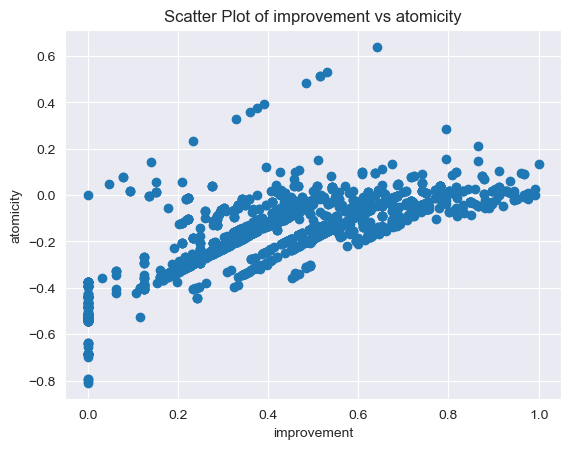

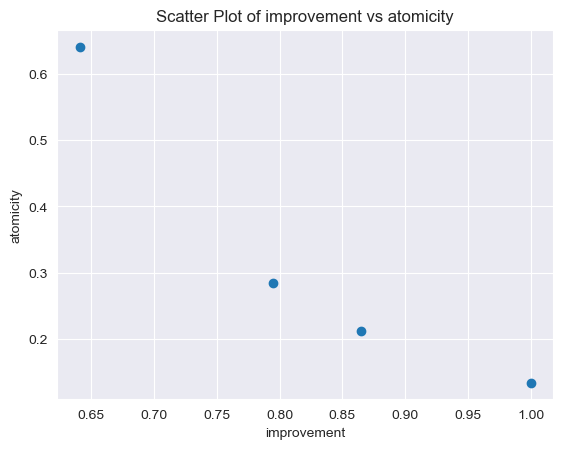

[0 * * * * * *]	0.640625, 0.641
[1 * 0 0 * * *]	0.7946428571428571, 0.284
[1 0 0 * 0 0 0]	0.8650793650793651, 0.212
[1 0 0 1 0 0 0]	1.0, 0.135


In [18]:
objectives = np.array([[improvement, atomicity] for ps,improvement, atomicity in pss_scores])
utils.simple_scatterplot(xs = objectives[:, 0].ravel(), ys = objectives[:, 1].ravel(), x_label="improvement", y_label="atomicity")
#print(objectives)
po_indices = get_pareto_optimal_indices(objectives)
optimal_pss = [pss_scores[index][0] for index in po_indices]

optimal_objectives = objectives[po_indices]
utils.simple_scatterplot(xs = optimal_objectives[:, 0].ravel(), ys = optimal_objectives[:, 1].ravel(), x_label="improvement", y_label="atomicity")

for index in po_indices:
    ps, improvement, atomicity = pss_scores[index]
    print(f"{ps}\t{improvement}, {atomicity:.3f}")